# DH412 331

# 1. Data Preprocessing

We noticed that the composition of the competition varied slightly across years (e.g., some years included free variation, some included contemporary variation, and some included both). However, every year included at least one classical variation, so we focus on analyzing how gestures evolved in the classical variation.

Here is our data preprocessing pipeline:

Firstly, we identified and corrected several errors in the metadata:

`edition35/edition35_sequence_32.mp4` (2007): The music should be *La Bayadère -- Gamzatti variation*.

`edition23/edition23_sequence_23.mp4` (1995): This is *free* instead of classical.

`edition29/edition29_sequence_10.mp4` (2001): This is *classical* instead of free.

`edition22/edition22_sequence_28.mp4` (1994): This is *free* instead of classical.

`edition23/edition23_sequence_19.mp4` (1995): This is *free* instead of classical.

`edition25/edition25_sequence_26.mp4` (1997): This is *free* instead of classical.

There are some lines labeled "results" that simply repeat dancers and their results; these redundant lines were removed.

In 2006 and 2007, finalists performed two classical variations, so we manually selected the one with costume by reviewing the competition videos.

In years such as 1976, some dancers only had videos for free variation and no classical variation. These cases were excluded from the movement evolution analysis but retained for other analyses.

For 2022 and 2023, results were available but the "has_award" column was not labeled, so we manually added the corresponding labels.

There are no results for 2025 and no information at all for 2026. These results (as well as 2026 videos) were manually added.

For the years 1973, 1974, 1975, 1977, 1980, 1989, 2004, and 2015, only photos are available. Videos for 2004 and 2015 may exist online. The other years cannot be used for movement evolution analysis but are retained for other analyses.

Finally, we keep two tables. The first table includes all dancers with a contemporary variation performance (we keep the corresponding row), and it is used for movement evolution analysis; the second table includes all dancers in the competition (we keep the contemporary variation row if available, otherwise a random other row), and it is used for all other analyses.

As previously described, a lot of steps can only be done manually. We performed all manual tasks first and obtained the XLSX file `data_Prix_2025_manually filtered and fixed.xlsx`. The rest part of the preprocessing were completed through coding, and we showed the code below.

In [1]:
import pandas as pd

df = pd.read_excel("data_Prix_2025_manually filtered and fixed.xlsx")

print(df.head())
print(df.info())
print(df.shape)

                   filename   surname      name  year edition dancer_id  \
0  Bayard_Sylviane_1973.tif    Bayard  Sylviane  1973     1st    1973_A   
1     Cassiman_Kym_1973.tif  Cassiman       Kym  1973     1st    1973_B   
2    de_Graef_Marc_1973.tif  de Graef      Marc  1973     1st    1973_C   
3      Eger_Judith_1973.tif      Eger    Judith  1973     1st    1973_D   
4   Gascard_Michel_1973.tif   Gascard    Michel  1973     1st    1973_E   

  countries perf_type awards  has_award performance  thumbnail_frame  res  \
0    France     photo    NaN        1.0         NaN              NaN  NaN   
1   Belgium     photo    NaN        0.0         NaN              NaN  NaN   
2   Belgium     photo    NaN        0.0         NaN              NaN  NaN   
3    Canada     photo    NaN        0.0         NaN              NaN  NaN   
4    France     photo    NaN        1.0         NaN              NaN  NaN   

   frame_count performance_translated perf_clean  has_thumbnail  \
0          NaN     

In [2]:
df = df[df['perf_type'] != 'results']

In [3]:
print(df.shape)

(1591, 19)


In [4]:
import pandas as pd

priority_map = {
    'classical': 1,
    'contemporary': 2,
    'free': 3
}

df1 = df[df['perf_type'] == 'classical'].copy()
df1 = df1.drop_duplicates(subset=['surname', 'name', 'year'])
df2 = df.copy()

df2['priority'] = df2['perf_type'].map(priority_map).fillna(4)

df2 = df2.sort_values(by=['surname', 'name', 'year', 'priority'])

df2 = df2.drop_duplicates(subset=['surname', 'name', 'year'], keep='first')

df2 = df2.drop(columns=['priority'])

print(f"df1 shape (Classical only): {df1.shape}")
print(f"df2 shape (Priority based): {df2.shape}")

df1 shape (Classical only): (753, 19)
df2 shape (Priority based): (863, 19)


In [5]:

df1.to_csv('analysis_movement.xlsx', index=False, encoding='utf-8-sig')
df1.to_csv('analysis_movement.csv', index=False, encoding='utf-8-sig')

df2.to_csv('analysis_other.xlsx', index=False, encoding='utf-8-sig')
df2.to_csv('analysis_other.csv', index=False, encoding='utf-8-sig')


# 2. Exploratory Data Analysis

As previously said, we will use `analysis_other.csv` to do any statistical analysis.

In [6]:
df=df2
df.shape

(863, 19)

## 2.1 Country

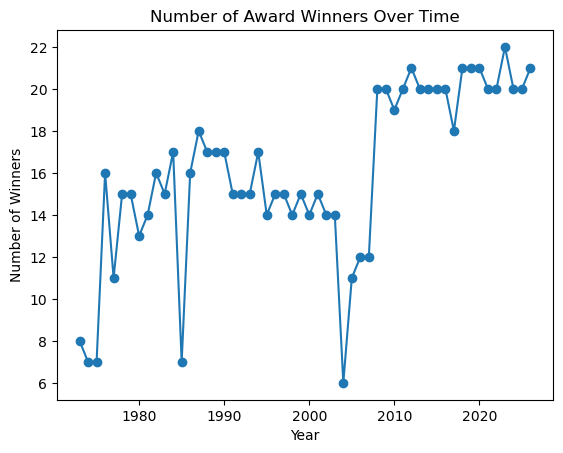

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

year_min = df["year"].min()
year_max = df["year"].max()
all_years = pd.Series(range(year_min, year_max + 1), name="year")

winners_per_year = df.groupby("year").size()

winners_per_year = winners_per_year.reindex(all_years, fill_value=0)

plt.figure()
winners_per_year.plot(marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Number of Award Winners Over Time")
plt.show()

<Figure size 640x480 with 0 Axes>

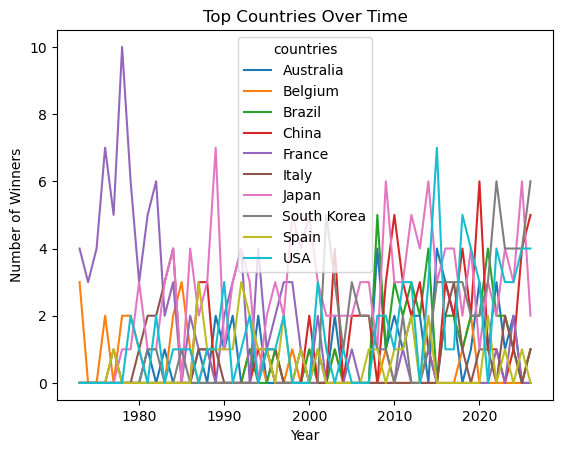

In [8]:
top_countries = df["countries"].value_counts().head(10).index

df_top = df[df["countries"].isin(top_countries)]

country_year = df_top.groupby(["year", "countries"]).size().unstack(fill_value=0)

plt.figure()
country_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Top Countries Over Time")
plt.show()

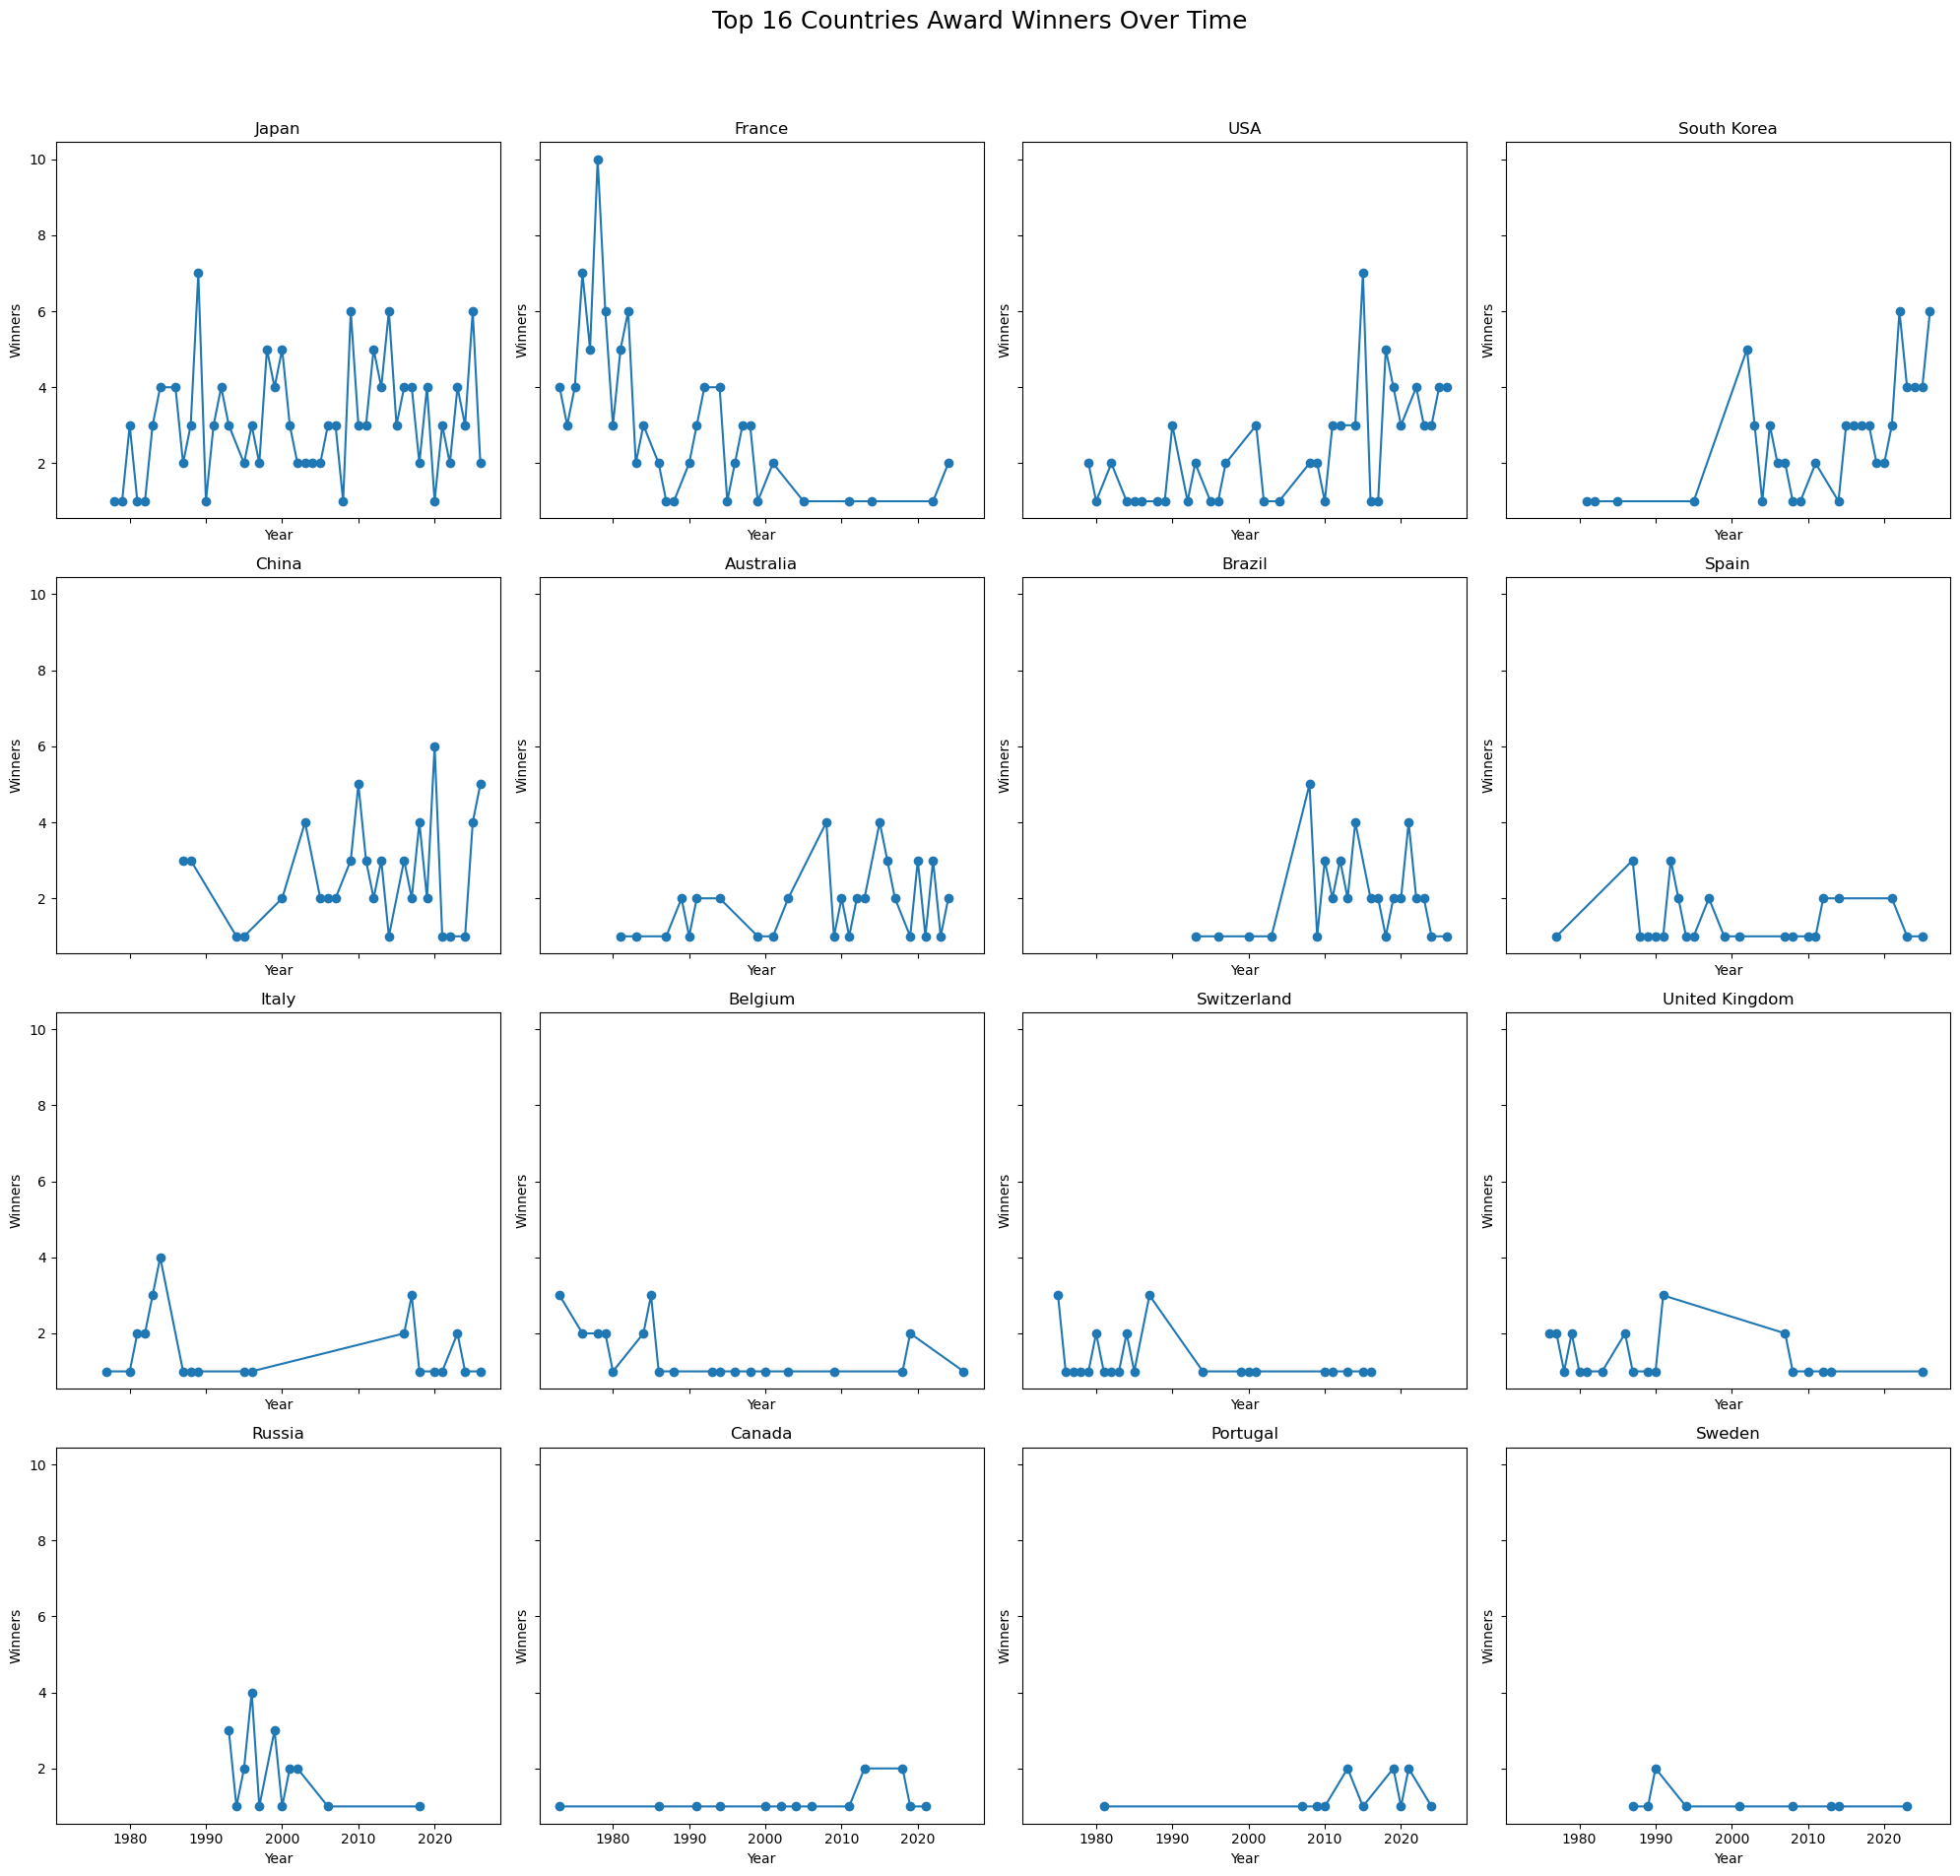

In [9]:
# Top 16 countries
top_16_countries = df["countries"].value_counts().head(16).index

# plot 4*4
fig, axes = plt.subplots(4, 4, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten() 

for i, country in enumerate(top_16_countries):
    data = df[df["countries"] == country]
    winners_per_year = data.groupby("year").size()
    
    axes[i].plot(winners_per_year.index, winners_per_year.values, marker='o')
    axes[i].set_title(country)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Winners")

plt.suptitle("Top 16 Countries Award Winners Over Time", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

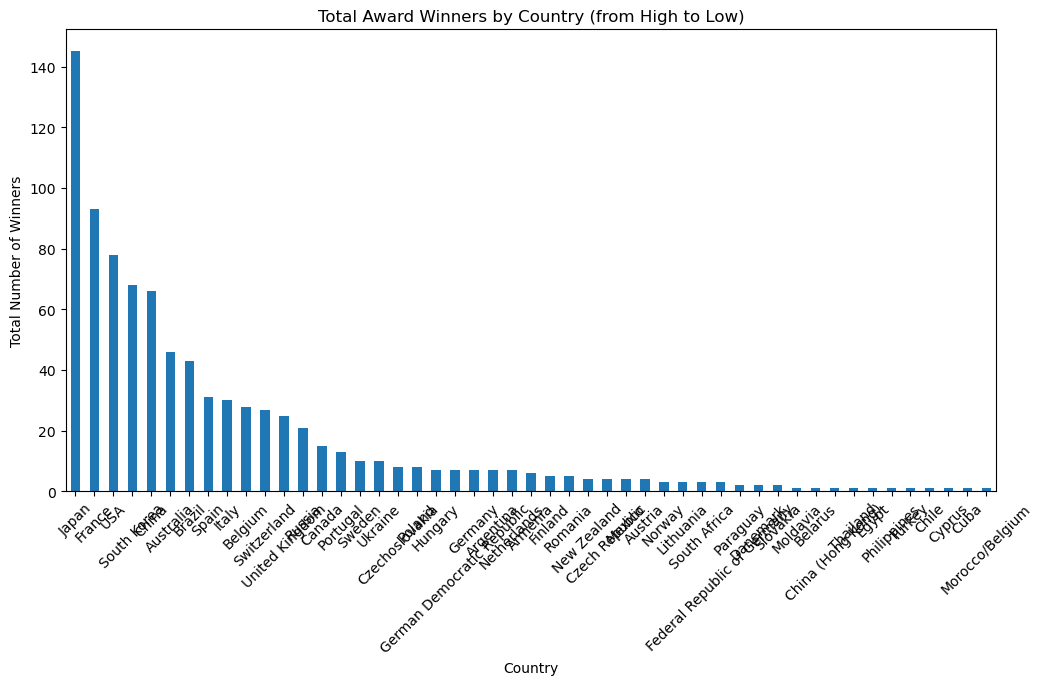

In [10]:
country_counts = df["countries"].value_counts()

plt.figure(figsize=(12, 6))
country_counts.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Total Number of Winners")
plt.title("Total Award Winners by Country (from High to Low)")
plt.xticks(rotation=45)
plt.show()

By decades

=== 1970s ===
['(France, 39)', '(Belgium, 9)', '(Switzerland, 7)']
=== 1980s ===
['(Japan, 28)', '(France, 23)', '(Italy, 15)']
=== 1990s ===
['(Japan, 27)', '(France, 23)', '(Russia, 14)']
=== 2000s ===
['(Japan, 29)', '(South Korea, 18)', '(China, 15)']
=== 2010s ===
['(Japan, 38)', '(USA, 28)', '(China, 25)']
=== 2020s ===
['(South Korea, 29)', '(Japan, 21)', '(USA, 21)']


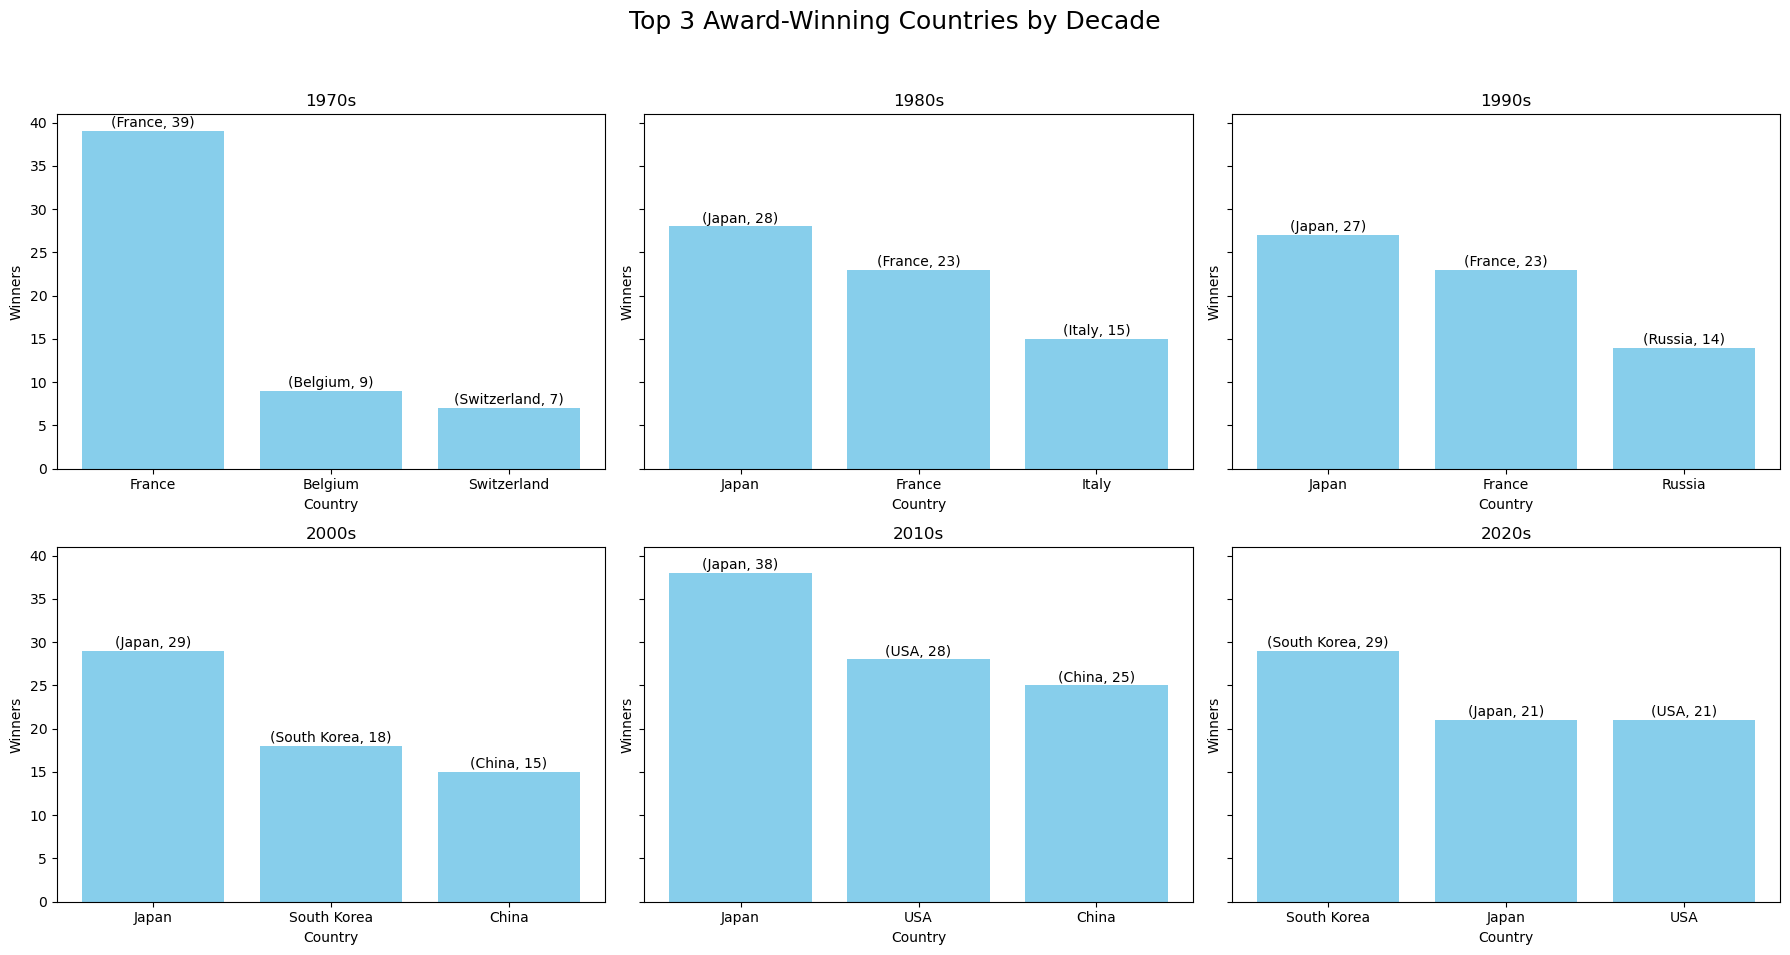

In [11]:
df = df.copy()
df['decade'] = (df['year'] // 10) * 10

decade_country_counts = df.groupby(['decade', 'countries']).size().reset_index(name='count')

top3_per_decade = (
    decade_country_counts
    .sort_values(['decade', 'count'], ascending=[True, False])
    .groupby('decade', group_keys=False)
    .head(3)
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, decade in enumerate(sorted(top3_per_decade['decade'].unique())):
    df_decade = top3_per_decade[top3_per_decade['decade'] == decade]
    
    print(f"=== {decade}s ===")
    print([f"({row['countries']}, {row['count']})" for _, row in df_decade.iterrows()])
    
    bars = axes[i].bar(df_decade['countries'], df_decade['count'], color='skyblue')
    axes[i].set_title(f"{decade}s")
    axes[i].set_xlabel("Country")
    axes[i].set_ylabel("Winners")
    for bar, country, count in zip(bars, df_decade['countries'], df_decade['count']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"({country}, {count})", 
                     ha='center', va='bottom', fontsize=10)

plt.suptitle("Top 3 Award-Winning Countries by Decade", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 2.2 Continent

In [12]:
unique_countries = df['countries'].unique()
print(sorted(df['countries'].dropna().unique()))

['Argentina', 'Armenia', 'Australia', 'Austria', 'Belarus', 'Belgium', 'Brazil', 'Canada', 'Chile', 'China', 'China (Hong Kong)', 'Cuba', 'Cyprus', 'Czech Republic', 'Czechoslovakia', 'Danemark', 'Egypt', 'Federal Republic of Germany', 'Finland', 'France', 'German Democratic Republic', 'Germany', 'Hungary', 'Italy', 'Japan', 'Lithuania', 'Mexico', 'Moldavia', 'Morocco/Belgium', 'Netherlands', 'New Zealand', 'Norway', 'Paraguay', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Turkey', 'USA', 'Ukraine', 'United Kingdom']


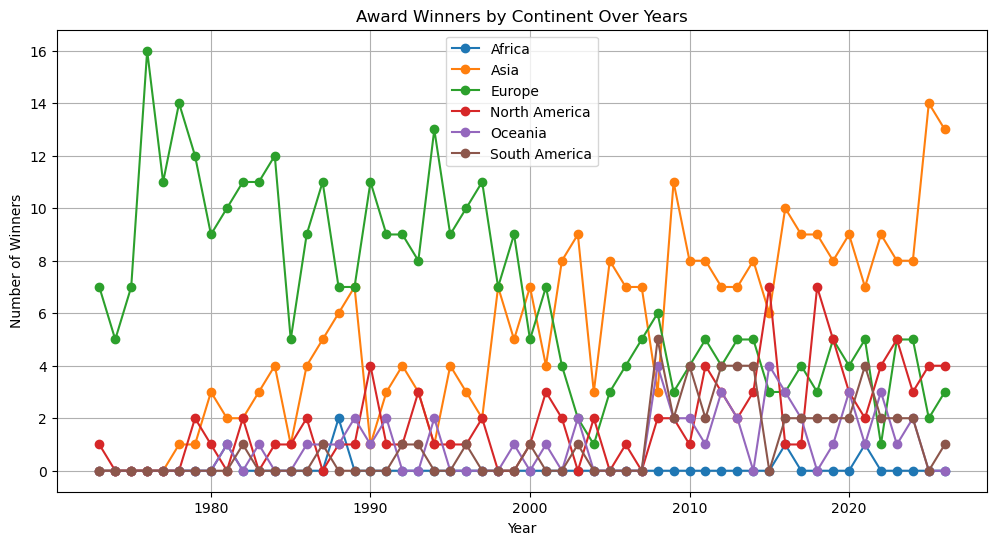

In [13]:
country_to_continent = {
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Brazil': 'South America',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Cuba': 'North America',
    'Cyprus': 'Europe',
    'Czech Republic': 'Europe',
    'Czechoslovakia': 'Europe',
    'Danemark': 'Europe',
    'Egypt': 'Africa',
    'Federal Republic of Germany': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'German Democratic Republic': 'Europe',
    'Germany': 'Europe',
    'Hungary': 'Europe',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Lithuania': 'Europe',
    'Mexico': 'North America',
    'Moldavia': 'Europe',
    'Morocco/Belgium': 'Africa',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Norway': 'Europe',
    'Paraguay': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Romania': 'Europe',
    'Russia': 'Europe',
    'Slovakia': 'Europe',
    'South Africa': 'Africa',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Thailand': 'Asia',
    'USA': 'North America',
    'Ukraine': 'Europe',
    'United Kingdom': 'Europe'
}

df = df.copy()
df['continent'] = df['countries'].map(country_to_continent)

all_years = range(df['year'].min(), df['year'].max()+1)

continent_year = df.groupby(['year','continent']).size().unstack(fill_value=0)

continent_year = continent_year.reindex(all_years, fill_value=0)

plt.figure(figsize=(12,6))
for continent in continent_year.columns:
    plt.plot(continent_year.index, continent_year[continent], marker='o', label=continent)

plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Award Winners by Continent Over Years")
plt.legend()
plt.grid(True)
plt.show()

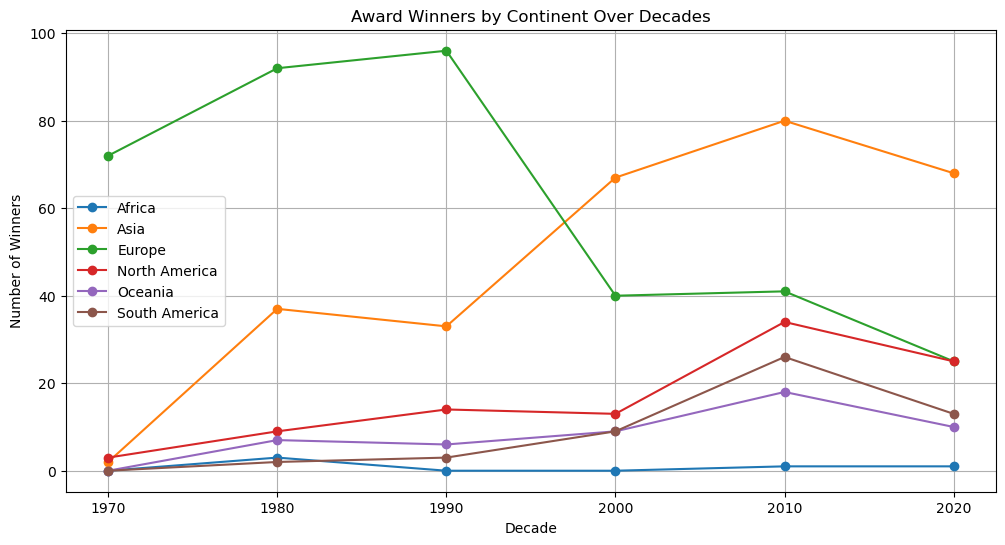

In [14]:
country_to_continent = {
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Brazil': 'South America',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Cuba': 'North America',
    'Cyprus': 'Europe',
    'Czech Republic': 'Europe',
    'Czechoslovakia': 'Europe',
    'Danemark': 'Europe',
    'Egypt': 'Africa',
    'Federal Republic of Germany': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'German Democratic Republic': 'Europe',
    'Germany': 'Europe',
    'Hungary': 'Europe',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Lithuania': 'Europe',
    'Mexico': 'North America',
    'Moldavia': 'Europe',
    'Morocco/Belgium': 'Africa',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Norway': 'Europe',
    'Paraguay': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Romania': 'Europe',
    'Russia': 'Europe',
    'Slovakia': 'Europe',
    'South Africa': 'Africa',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Thailand': 'Asia',
    'USA': 'North America',
    'Ukraine': 'Europe',
    'United Kingdom': 'Europe'
}

df = df.copy()
df['continent'] = df['countries'].map(country_to_continent)
df['decade'] = (df['year'] // 10) * 10

continent_decade = df.groupby(['decade','continent']).size().unstack(fill_value=0)

all_decades = range(df['decade'].min(), df['decade'].max()+10, 10)
continent_decade = continent_decade.reindex(all_decades, fill_value=0)

plt.figure(figsize=(12,6))
for continent in continent_decade.columns:
    plt.plot(continent_decade.index, continent_decade[continent], marker='o', label=continent)

plt.xlabel("Decade")
plt.ylabel("Number of Winners")
plt.title("Award Winners by Continent Over Decades")
plt.legend()
plt.grid(True)
plt.show()

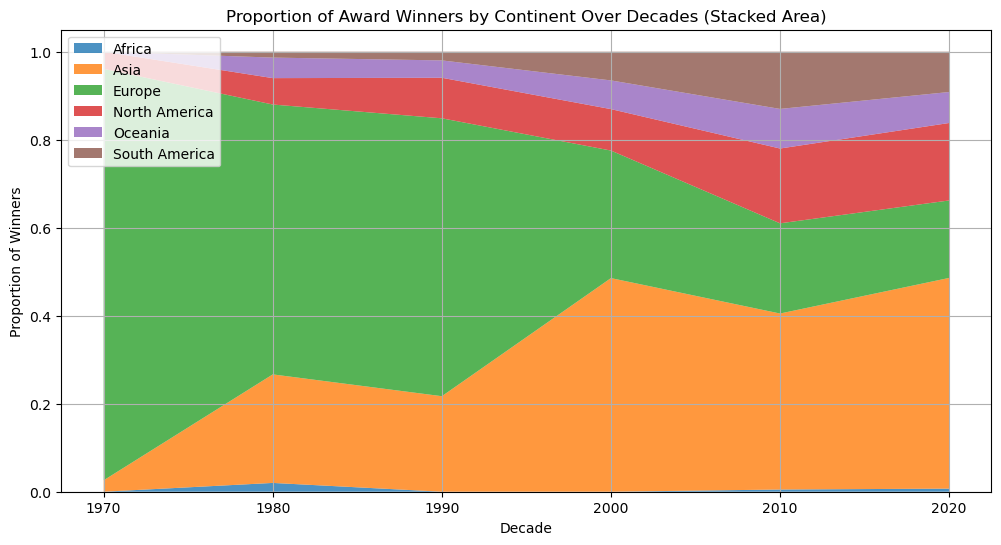

In [15]:
df['decade'] = (df['year'] // 10) * 10
continent_decade = df.groupby(['decade','continent']).size().unstack(fill_value=0)

all_decades = range(df['decade'].min(), df['decade'].max()+10, 10)
continent_decade = continent_decade.reindex(all_decades, fill_value=0)

continent_decade_prop = continent_decade.div(continent_decade.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.stackplot(
    continent_decade_prop.index,
    [continent_decade_prop[col] for col in continent_decade_prop.columns],  
    labels=continent_decade_prop.columns,
    alpha=0.8
)

plt.xlabel("Decade")
plt.ylabel("Proportion of Winners")
plt.title("Proportion of Award Winners by Continent Over Decades (Stacked Area)")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

## 2.3 Gender

#### GPT Gender Classification

Since this is not a publicly available dataset, we only extracted the names and used multiple large local models for gender labeling and cross-comparison.

In [16]:
df_name = pd.DataFrame()
df_name['full_name'] = df['surname'] + ' ' + df['name']

In [17]:
df_name.head()

,full_name
1616,Abdel-Nour Luca
243,Abegglen Peter
15,Acatos Sibylle
1362,Acevedo Austen
429,Acosta Carlos


In [18]:
df['full_name'] = df['surname'] + ' ' + df['name']

In [19]:
df_name.to_csv('full_names.csv', index=False, encoding='utf-8-sig')

In [20]:
df.to_csv('analysis_other_1.csv', index=False, encoding='utf-8-sig')

The prompt we used:

I have a list containing names (see below). Please label each member's gender (male/female) according to naming conventions.

Requirements:

Please return the results directly as a Markdown table, adding a "Gender" column.

Do not output any extraneous explanatory text.

Please save the results to a CSV file and provide a download link.

We sent all names to 5 LLMs and let them label the gender independently, and then measure the alignment.

In [21]:
df2 = pd.read_csv('names_with_genders.csv', encoding='latin1')

df2['Gender 1'] = df2['Gender 1'].astype(str).str.lower()
df2['Gender 2'] = df2['Gender 2'].astype(str).str.lower()
df2['Gender 3'] = df2['Gender 3'].astype(str).str.lower()
df2['Gender 4'] = df2['Gender 4'].astype(str).str.lower()
df2['Gender 5'] = df2['Gender 5'].astype(str).str.lower()

is_all_same = (df2['Gender 1'] == df2['Gender 2']) & (df2['Gender 2'] == df2['Gender 3']) & (df2['Gender 3'] == df2['Gender 4']) & (df2['Gender 4'] == df2['Gender 5'])

same_count = is_all_same.sum()
different_count = (~is_all_same).sum()

print(f"Number of rows with all three genders same: {same_count}")
print(f"Number of rows with different genders: {different_count}")

Number of rows with all three genders same: 779
Number of rows with different genders: 84


In [22]:
df2.shape

(863, 6)

In [23]:
total_rows = len(df)

match_1_2 = (df2['Gender 1'] == df2['Gender 2']).sum()
match_1_3 = (df2['Gender 1'] == df2['Gender 3']).sum()
match_1_4 = (df2['Gender 1'] == df2['Gender 4']).sum()
match_1_5 = (df2['Gender 1'] == df2['Gender 5']).sum()
match_2_3 = (df2['Gender 2'] == df2['Gender 3']).sum()
match_2_4 = (df2['Gender 2'] == df2['Gender 4']).sum()
match_2_5 = (df2['Gender 2'] == df2['Gender 5']).sum()
match_3_4 = (df2['Gender 3'] == df2['Gender 4']).sum()
match_3_5 = (df2['Gender 3'] == df2['Gender 5']).sum()
match_4_5 = (df2['Gender 4'] == df2['Gender 5']).sum()

align_1_2 = match_1_2 / total_rows
align_1_3 = match_1_3 / total_rows
align_1_4 = match_1_4 / total_rows
align_1_5 = match_1_5 / total_rows
align_2_3 = match_2_3 / total_rows
align_2_4 = match_2_4 / total_rows
align_2_5 = match_2_5 / total_rows
align_3_4 = match_3_4 / total_rows
align_3_5 = match_3_5 / total_rows
align_4_5 = match_4_5 / total_rows

print(f"Alignment Gender 1 vs Gender 2: {align_1_2:.2%} ({match_1_2}/{total_rows})")
print(f"Alignment Gender 1 vs Gender 3: {align_1_3:.2%} ({match_1_3}/{total_rows})")
print(f"Alignment Gender 1 vs Gender 4: {align_2_3:.2%} ({match_1_4}/{total_rows})")
print(f"Alignment Gender 1 vs Gender 5: {align_1_2:.2%} ({match_1_5}/{total_rows})")
print(f"Alignment Gender 2 vs Gender 3: {align_1_3:.2%} ({match_2_3}/{total_rows})")
print(f"Alignment Gender 2 vs Gender 4: {align_2_3:.2%} ({match_2_4}/{total_rows})")
print(f"Alignment Gender 2 vs Gender 5: {align_1_2:.2%} ({match_2_5}/{total_rows})")
print(f"Alignment Gender 3 vs Gender 4: {align_1_3:.2%} ({match_3_4}/{total_rows})")
print(f"Alignment Gender 3 vs Gender 5: {align_2_3:.2%} ({match_3_5}/{total_rows})")
print(f"Alignment Gender 4 vs Gender 5: {align_1_2:.2%} ({match_4_5}/{total_rows})")

Alignment Gender 1 vs Gender 2: 94.55% (816/863)
Alignment Gender 1 vs Gender 3: 92.00% (794/863)
Alignment Gender 1 vs Gender 4: 95.13% (805/863)
Alignment Gender 1 vs Gender 5: 94.55% (815/863)
Alignment Gender 2 vs Gender 3: 92.00% (821/863)
Alignment Gender 2 vs Gender 4: 95.13% (824/863)
Alignment Gender 2 vs Gender 5: 94.55% (840/863)
Alignment Gender 3 vs Gender 4: 92.00% (846/863)
Alignment Gender 3 vs Gender 5: 95.13% (838/863)
Alignment Gender 4 vs Gender 5: 94.55% (841/863)


In [24]:
gender_cols = ['Gender 1', 'Gender 2', 'Gender 3', 'Gender 4', 'Gender 5']

def get_possible_gender(row):
    counts = row[gender_cols].value_counts()
    male_count = counts.get('male', 0)
    female_count = counts.get('female', 0)
    
    if male_count == 5:
        return 'male'
    elif female_count == 5:
        return 'female'
    elif male_count > female_count:
        return 'likely male'
    else:
        return 'likely female'

df2['Possible Gender'] = df2.apply(get_possible_gender, axis=1)

df['full_name'] = df['surname'] + ' ' + df['name']

In [25]:
df_sorted = df.sort_values('full_name').reset_index(drop=True)
df2_sorted = df2.sort_values('full_name').reset_index(drop=True)

In [26]:
df_sorted['possible_gender'] = df2_sorted['Possible Gender']

In [27]:
df=df_sorted

In [28]:
df.to_csv('analysis_other_guessed_gender.csv', index=False, encoding='utf-8-sig')